In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from PIL import Image

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    classification_report,
)
from pathlib import Path

In [2]:
EMBEDDINGS_DIR = Path("embeddings")

resnetdf = pd.read_csv(EMBEDDINGS_DIR / "resnet50_embeddings.csv")
efnetdf  = pd.read_csv(EMBEDDINGS_DIR / "efficientnet_b4_embeddings.csv")

print(f"resnetdf : {resnetdf.shape}")
print(f"efnetdf  : {efnetdf.shape}")

resnetdf : (1506, 2050)
efnetdf  : (1506, 1794)


# Choix du modèle à utiliser pour le clustering

In [3]:
df = efnetdf.copy()

In [4]:
modele = "EfficientNet-B4"

# Separation Train Test


In [5]:
test_df   = df[df["label"].isin([0, 1])] 
train_df = df[df["label"]==-1]
X=train_df.drop(columns=["label", "image_path"])

# Standardisation

In [6]:
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.shape

(1406, 1792)

# PCA

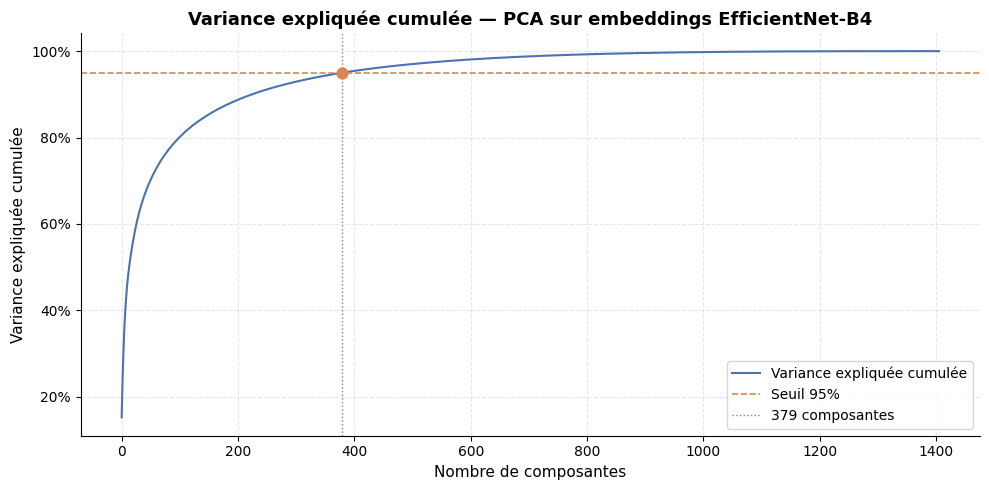

379 dimensions à garder pour conserver 95% de la variance


In [7]:
pcamodel = PCA(n_components=min(X_scaled.shape), random_state=42)
pcamodel.fit(X_scaled)

cumvar = np.cumsum(pcamodel.explained_variance_ratio_)
dim = np.argmax(cumvar > 0.95)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(cumvar, color="#4C72B0", linewidth=1.5, label="Variance expliquée cumulée")
ax.axhline(0.95, color="#DD8452", linewidth=1.2, linestyle="--", label="Seuil 95%")
ax.axvline(dim, color="gray", linewidth=1, linestyle=":", label=f"{dim} composantes")
ax.scatter([dim], [cumvar[dim]], color="#DD8452", zorder=5, s=60)

ax.set_title(f"Variance expliquée cumulée — PCA sur embeddings {modele}", fontsize=13, fontweight="bold")
ax.set_xlabel("Nombre de composantes", fontsize=11)
ax.set_ylabel("Variance expliquée cumulée", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

print(f"{dim} dimensions à garder pour conserver 95% de la variance")

In [8]:
pcamodel = PCA(n_components=dim)
pcamodel.fit(X_scaled)
X_pca = pcamodel.transform(X_scaled)
X_pca.shape


(1406, 379)

# Clustering

In [9]:
gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=42)

In [10]:
gmm.fit(X_pca)
cluster_labels = gmm.predict(X_pca)

In [11]:
# Add cluster labels back to train_df
train_df = train_df.copy()
train_df["cluster"] = cluster_labels

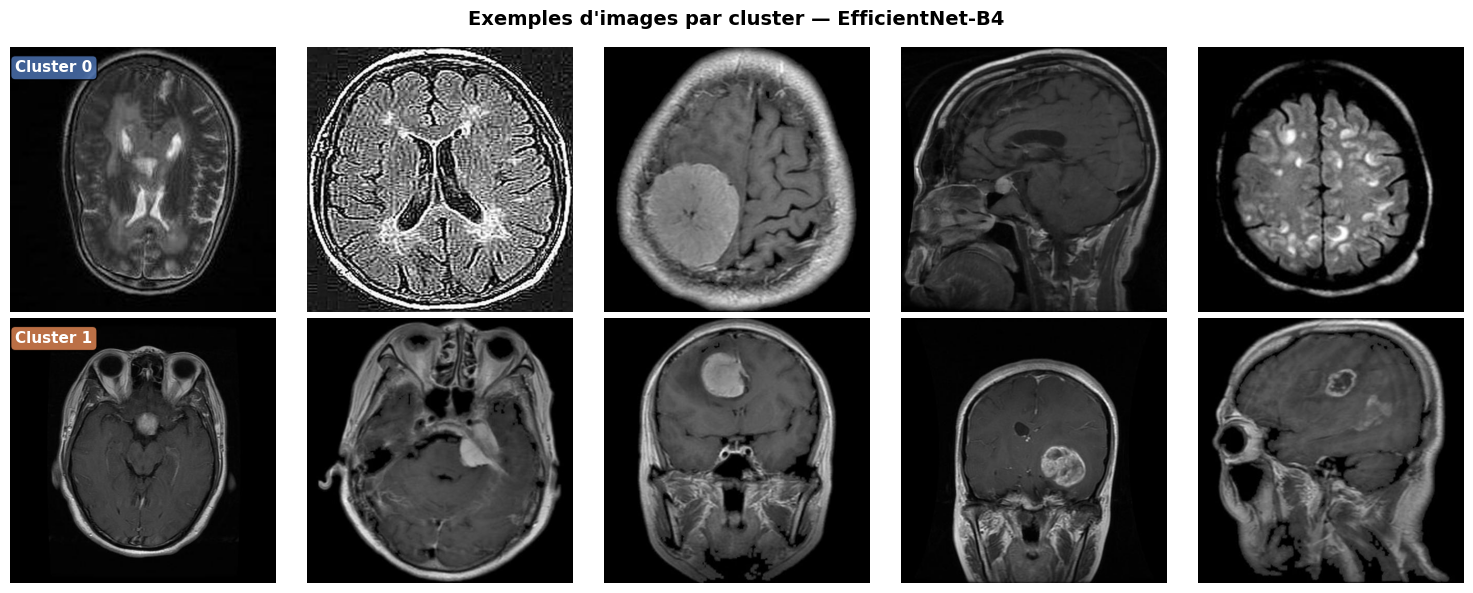

In [36]:
from PIL import Image

CLUSTER_COLORS = {0: "#4C72B0", 1: "#DD8452"}
n_samples = 5
clusters = [0, 1]
fig, axes = plt.subplots(len(clusters), n_samples, figsize=(15, 6))
fig.suptitle(f"Exemples d'images par cluster — {modele}", fontsize=14, fontweight="bold")

for row_idx, cluster_id in enumerate(clusters):
    sample_paths = (
        train_df[train_df["cluster"] == cluster_id]["image_path"]
        .sample(n_samples, random_state=21)
        .tolist()
    )
    for col_idx, path in enumerate(sample_paths):
        ax = axes[row_idx][col_idx]
        with Image.open(path) as img:
            ax.imshow(img)
        ax.axis("off")

    axes[row_idx][0].text(
        0.02, 0.95, f"Cluster {cluster_id}",
        transform=axes[row_idx][0].transAxes,
        fontsize=11, fontweight="bold", color="white",
        va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.3", facecolor=CLUSTER_COLORS[cluster_id], alpha=0.85),
    )

plt.tight_layout()
plt.show()

In [13]:
sil = silhouette_score(X_pca, cluster_labels)
bic = gmm.bic(X_pca)
aic = gmm.aic(X_pca)

print(f"Silhouette : {sil:.4f}  (plus proche de 1 = meilleur)")
print(f"BIC        : {bic:.1f}  (plus bas = meilleur)")
print(f"AIC        : {aic:.1f}  (plus bas = meilleur)")
print(f"Converged  : {gmm.converged_}  (itérations : {gmm.n_iter_})")

Silhouette : 0.1174  (plus proche de 1 = meilleur)
BIC        : 2408896.3  (plus bas = meilleur)
AIC        : 1649023.1  (plus bas = meilleur)
Converged  : True  (itérations : 3)


# Visualisation

In [14]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

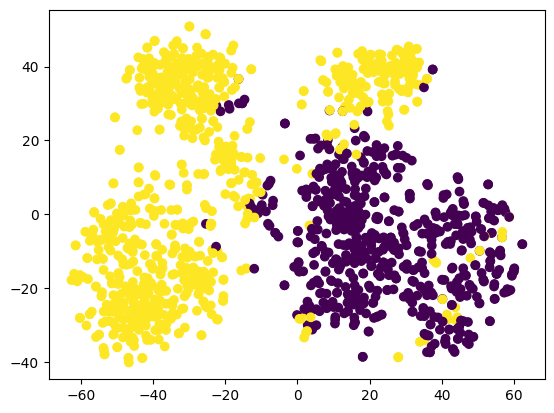

In [15]:
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels)

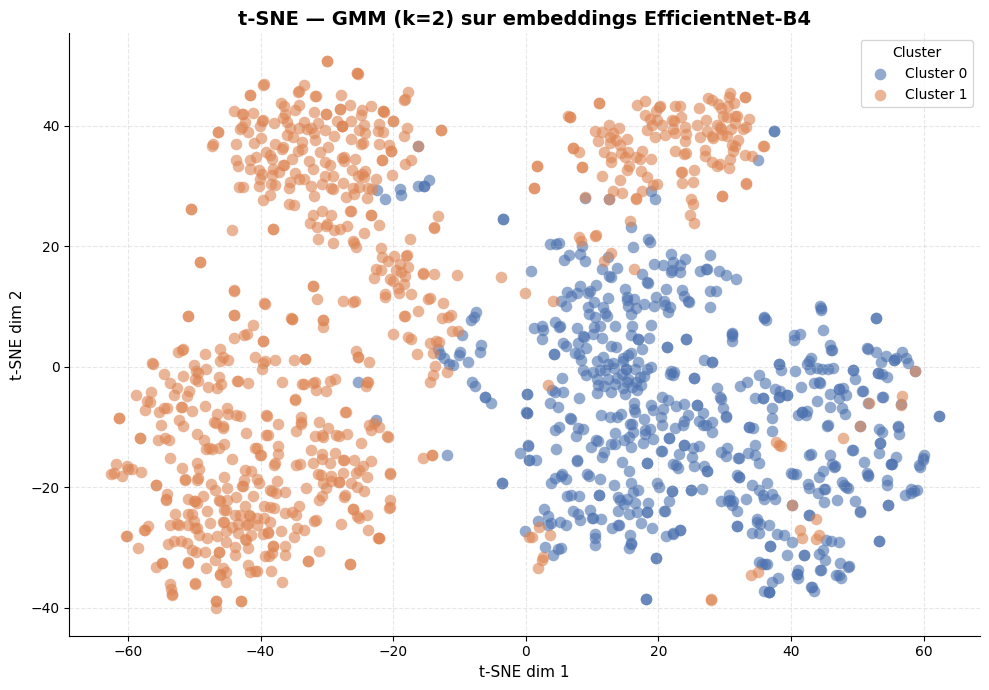

In [38]:
CLUSTER_COLORS = {0: "#4C72B0", 1: "#DD8452"}

fig, ax = plt.subplots(figsize=(10, 7))

for cluster_id, color in CLUSTER_COLORS.items():
    mask = cluster_labels == cluster_id
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=color, label=f"Cluster {cluster_id}",
        alpha=0.6, s=70, linewidths=0,
    )

ax.set_title(f"t-SNE — GMM (k=2) sur embeddings {modele}", fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE dim 1", fontsize=11)
ax.set_ylabel("t-SNE dim 2", fontsize=11)
ax.legend(title="Cluster", fontsize=10, title_fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

# SCORES

Mapping retenu : cluster 0 → normal, cluster 1 → cancer

  Accuracy   : 0.7800
  Precision  : 0.7917  (cancer=positif)
  Recall     : 0.7600  (cancer=positif)
  F1-score   : 0.7755
  F2-score   : 0.7661  (recall x2)
  ARI        : 0.3066

              precision    recall  f1-score   support

      Normal       0.77      0.80      0.78        50
      Cancer       0.79      0.76      0.78        50

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.78      0.78      0.78       100



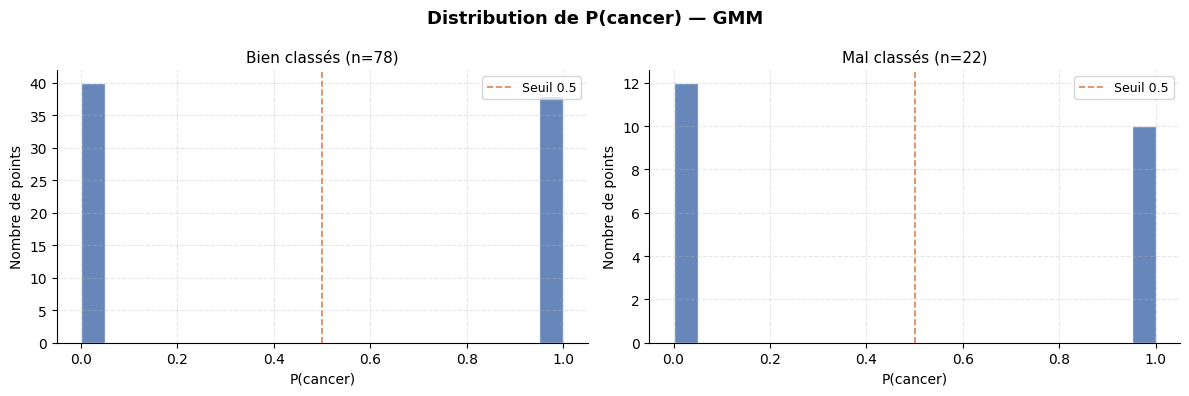

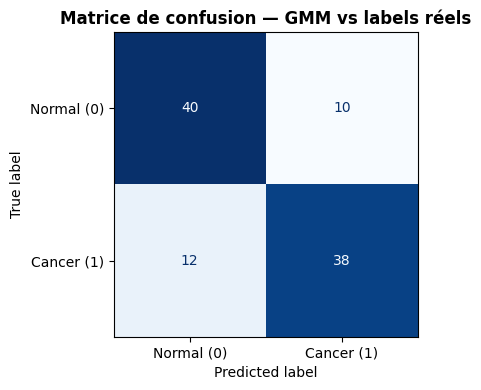

In [39]:
X_test = test_df.drop(columns=["label", "image_path"])
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)
X_test_pca = pcamodel.transform(X_test_scaled)
cluster_pred = gmm.predict(X_test_pca)
proba_pred   = gmm.predict_proba(X_test_pca)   # shape (n, 2)
y_true = test_df["label"].values  # 0=normal, 1=cancer

# ── Alignement des labels ──────────────────────────────────────────────────
acc_direct   = (cluster_pred == y_true).mean()
acc_inverted = (1 - cluster_pred == y_true).mean()

if acc_direct >= acc_inverted:
    aligned_pred = cluster_pred
    cluster_to_class = {0: "normal", 1: "cancer"}
else:
    aligned_pred = 1 - cluster_pred
    cluster_to_class = {0: "cancer", 1: "normal"}

cancer_cluster = [c for c, name in cluster_to_class.items() if name == "cancer"][0]
proba_cancer = proba_pred[:, cancer_cluster]  # P(appartenir au cluster cancer)

ari = adjusted_rand_score(y_true, aligned_pred)
print(f"Mapping retenu : cluster 0 → {cluster_to_class[0]}, cluster 1 → {cluster_to_class[1]}\n")

# ── Métriques ──────────────────────────────────────────────────────────────
print("=" * 45)
print(f"  Accuracy   : {accuracy_score(y_true, aligned_pred):.4f}")
print(f"  Precision  : {precision_score(y_true, aligned_pred):.4f}  (cancer=positif)")
print(f"  Recall     : {recall_score(y_true, aligned_pred):.4f}  (cancer=positif)")
print(f"  F1-score   : {f1_score(y_true, aligned_pred):.4f}")
print(f"  F2-score   : {fbeta_score(y_true, aligned_pred, beta=2):.4f}  (recall x2)")
print(f"  ARI        : {ari:.4f}")
print("=" * 45)
print()
print(classification_report(y_true, aligned_pred, target_names=["Normal", "Cancer"]))

# ── Distribution des probabilités — bien vs mal classés ───────────────────
correct_mask = aligned_pred == y_true
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Distribution de P(cancer) — GMM", fontsize=13, fontweight="bold")

for ax, (label, mask) in zip(axes, [("Bien classés", correct_mask), ("Mal classés", ~correct_mask)]):
    n = mask.sum()
    ax.hist(proba_cancer[mask], bins=20, range=(0, 1), color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.axvline(0.5, color="#DD8452", linestyle="--", linewidth=1.2, label="Seuil 0.5")
    ax.set_title(f"{label} (n={n})", fontsize=11)
    ax.set_xlabel("P(cancer)", fontsize=10)
    ax.set_ylabel("Nombre de points", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.3)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

# ── Matrice de confusion ───────────────────────────────────────────────────
cm = confusion_matrix(y_true, aligned_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal (0)", "Cancer (1)"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title("Matrice de confusion — GMM vs labels réels", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Extractions

In [37]:
# ── Pseudo-labels GMM sur les 1406 images non labellisées ─────────────────
proba_train = gmm.predict_proba(X_pca)  # shape (1406, 2)

pseudo_df = pd.DataFrame({
    "image_path"   : train_df["image_path"].values,
    "pseudo_label" : [1 if cluster_to_class[c] == "cancer" else 0 for c in cluster_labels],
    "proba_cancer" : proba_train[:, cancer_cluster].round(4),
    "proba_normal" : proba_train[:, 1 - cancer_cluster].round(4),
})

print(f"Total : {len(pseudo_df)} images")
print(f"  pseudo-cancer (1) : {(pseudo_df['pseudo_label'] == 1).sum()}")
print(f"  pseudo-normal (0) : {(pseudo_df['pseudo_label'] == 0).sum()}\n")

out_path = Path("pseudo_labels_gmm.csv")
pseudo_df.to_csv(out_path, index=False)
print(f"Sauvegardé → {out_path}")

pseudo_df.head(10)

Total : 1406 images
  pseudo-cancer (1) : 787
  pseudo-normal (0) : 619

Sauvegardé → pseudo_labels_gmm.csv


,image_path,pseudo_label,proba_cancer,proba_normal
0,data\sans_label\001b158a-7af8-451e-bf31-3a9116...,1,1.0,0.0
1,data\sans_label\00366e8d-5520-4d3c-a70b-91a7ee...,0,0.0,1.0
2,data\sans_label\00455a62-f79f-4072-9a23-4951e7...,0,0.0,1.0
3,data\sans_label\004ce5f5-ca6b-490f-9b2f-c322c1...,1,1.0,0.0
4,data\sans_label\005d9a37-8894-4eb5-8367-1015d4...,1,1.0,0.0
5,data\sans_label\009e9d31-9f37-4d97-a941-815012...,1,1.0,0.0
6,data\sans_label\009eac4a-c951-4da9-852a-b32e9c...,1,1.0,0.0
7,data\sans_label\00e9e198-79de-47ab-9f4e-7b7615...,1,1.0,0.0
8,data\sans_label\01274f5e-3064-4efd-af4b-38e164...,1,1.0,0.0
9,data\sans_label\01717fbf-4bcf-475a-a718-361ed0...,1,1.0,0.0


In [40]:
# ── Test set avec vrais labels ─────────────────────────────────────────────
test_export_df = pd.DataFrame({
    "image_path"   : test_df["image_path"].values,
    "pseudo_label" : test_df["label"].values,   # vrais labels : 1=cancer, 0=normal
    "proba_cancer" : proba_pred[:, cancer_cluster].round(4),
    "proba_normal" : proba_pred[:, 1 - cancer_cluster].round(4),
})

print(f"Total : {len(test_export_df)} images")
print(f"  cancer (1) : {(test_export_df['pseudo_label'] == 1).sum()}")
print(f"  normal (0) : {(test_export_df['pseudo_label'] == 0).sum()}\n")

out_path_test = Path("true_labels_test.csv")
test_export_df.to_csv(out_path_test, index=False)
print(f"Sauvegardé → {out_path_test}")

test_export_df.head(10)

Total : 100 images
  cancer (1) : 50
  normal (0) : 50

Sauvegardé → true_labels_test.csv


,image_path,pseudo_label,proba_cancer,proba_normal
0,data\avec_labels\cancer\05340cd4-3bb2-459d-993...,1,1.0,0.0
1,data\avec_labels\cancer\0c6f3641-60d9-4a76-abe...,1,0.0,1.0
2,data\avec_labels\cancer\0f718241-8f63-4b55-81c...,1,1.0,0.0
3,data\avec_labels\cancer\11a7a426-4806-401e-98b...,1,1.0,0.0
4,data\avec_labels\cancer\1c043dbb-4623-4769-8e5...,1,1.0,0.0
5,data\avec_labels\cancer\27149ff6-8363-4942-a72...,1,1.0,0.0
6,data\avec_labels\cancer\2b810835-844c-49ff-b0f...,1,1.0,0.0
7,data\avec_labels\cancer\2d662cc1-509b-4657-a20...,1,1.0,0.0
8,data\avec_labels\cancer\2fa551e9-5b85-44f6-ab7...,1,1.0,0.0
9,data\avec_labels\cancer\3c3d07cb-ec2a-43b0-b8a...,1,1.0,0.0
